# Dataset Preview (HaluEval)

## Goals
1. Verify that the processed splits load correctly (`train/val/test`).
2. Show a simple “before/after” view: separate `prompt/response` vs. a combined `text` field.
3. Inspect basic distributions: `label`, `task`, and text lengths.
4. Display a few random examples of hallucinations vs. non-hallucinations.

> This notebook is intentionally lightweight and visual. It does not train models.


In [29]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 140)

# --- Repo bootstrap (running from notebooks/) ---
ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.load_splits import load_splits

train_df, val_df, test_df = load_splits(root=ROOT)

print("Train shape:", train_df.shape)
print("Val shape:  ", val_df.shape)
print("Test shape: ", test_df.shape)

# Use a stable sample for faster visuals
sample = train_df.sample(2000, random_state=42).copy()
sample.head(3)


Train shape: (51605, 6)
Val shape:   (6451, 6)
Test shape:  (6451, 6)


,id,task,prompt,response,label,context
672,qa_3566_gt,qa,What is the nickname of the leader of Christy Kinahan's rival gang?,The Monk,0,"The Hutch gang, led by Gerry Hutch, and the Kinahan gang, led by Christy Kinahan, are the main participants. Known for leading a ""disci..."
5428,qa_4187_gt,qa,What date was the screenwrither of the film directed by Garry Marshall born on?,"July 1, 1971",0,"Marc Silverstein (born July 1, 1971) is an American screenwriter. They are known for co-writing romantic comedy films such as ""Never Bee..."
13802,summarization_1130_hall,summarization,Ian Murray reckons a supposedly easier run-in can swing second place Hibs' way ahead of Rangers in the last month of the Championship se...,Former Rangers and Hibs player Ian Murray thinks Hibs will have an easier time securing second place in the Scottish Championship due to...,1,NaN


In [30]:
# BEFORE: prompt/response are stored separately (useful for feature engineering)
sample[["task", "label", "prompt", "response"]].head(2)

# AFTER: create a combined text field (useful for TF-IDF baselines)
sample = sample.copy()
sample["text"] = sample["prompt"].fillna("").astype(str) + "\n\n" + sample["response"].fillna("").astype(str)

sample[["task", "label", "text"]].head(2)


,task,label,text
672,qa,0,What is the nickname of the leader of Christy Kinahan's rival gang?\n\nThe Monk
5428,qa,0,"What date was the screenwrither of the film directed by Garry Marshall born on?\n\nJuly 1, 1971"


## Label distribution (Train)

Train label counts: {0: 27605, 1: 24000}


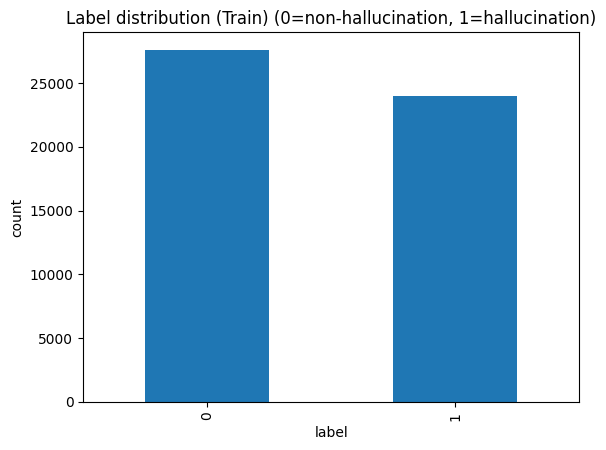

In [31]:
label_counts = train_df["label"].value_counts().sort_index()
print("Train label counts:", label_counts.to_dict())

label_counts.plot(kind="bar")
plt.title("Label distribution (Train) (0=non-hallucination, 1=hallucination)")
plt.xlabel("label")
plt.ylabel("count")
plt.show()


## Task distribution (Train)

Train task counts (top 20): {'dialogue': 16074, 'summarization': 15989, 'qa': 15935, 'general': 3607}


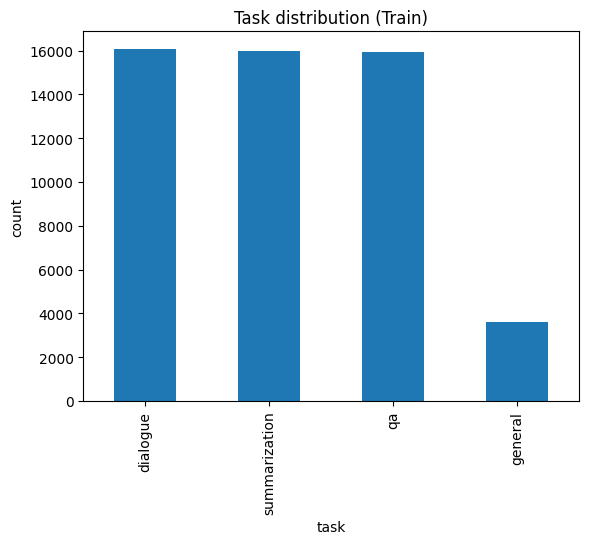

In [36]:
task_counts = train_df["task"].value_counts()
print("Train task counts (top 20):", task_counts.head(20).to_dict())

task_counts.plot(kind="bar")
plt.title("Task distribution (Train)")
plt.xlabel("task")
plt.ylabel("count")
plt.show()


## Length distributions (sample)

         prompt_len  response_len
count   2000.000000   2000.000000
mean    1261.695500    182.478500
std     1978.201955    197.168033
min       26.000000      1.000000
25%      102.000000     43.000000
50%      267.500000    102.000000
75%     1961.000000    275.000000
max    10586.000000   2252.000000


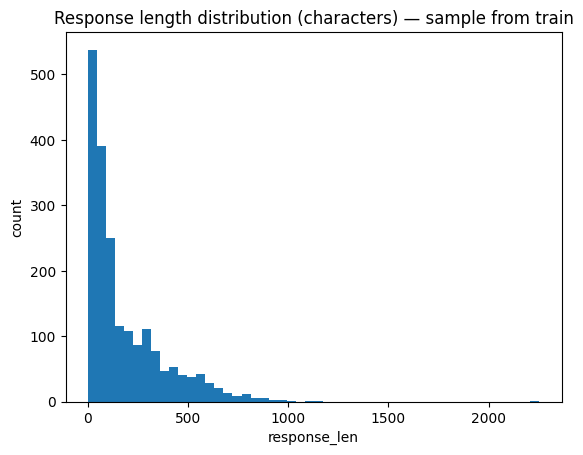

In [37]:
df2 = sample.copy()
df2["prompt_len"] = df2["prompt"].fillna("").astype(str).str.len()
df2["response_len"] = df2["response"].fillna("").astype(str).str.len()

print(df2[["prompt_len", "response_len"]].describe())

df2["response_len"].plot(kind="hist", bins=50)
plt.title("Response length distribution (characters) — sample from train")
plt.xlabel("response_len")
plt.ylabel("count")
plt.show()


## Length vs. label (boxplot, sample)

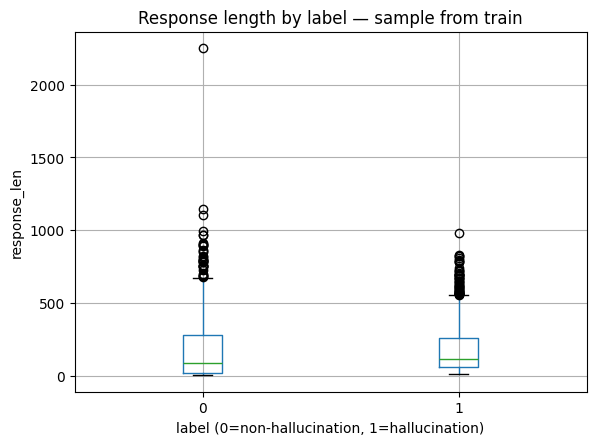

In [40]:
# Visual comparison: do hallucinations tend to be longer/shorter?
df2.boxplot(column="response_len", by="label")
plt.title("Response length by label — sample from train")
plt.suptitle("")  # remove pandas auto-title
plt.xlabel("label (0=non-hallucination, 1=hallucination)")
plt.ylabel("response_len")
plt.show()



## Random examples (train)

In [42]:
def show_examples(df: pd.DataFrame, label: int, n: int = 2, seed: int = 1, max_chars: int = 800) -> None:
    ex = df[df["label"] == label].sample(n, random_state=seed)
    for i, row in enumerate(ex.itertuples(index=False), 1):
        prompt = "" if pd.isna(row.prompt) else str(row.prompt)
        response = "" if pd.isna(row.response) else str(row.response)

        print("=" * 100)
        print(f"Example #{i} | task={row.task} | label={row.label}")
        print("- prompt:")
        print(prompt[:max_chars] + (" ..." if len(prompt) > max_chars else ""))
        print("\n- response:")
        print(response[:max_chars] + (" ..." if len(response) > max_chars else ""))

print("### Examples: Hallucination (label=1)")
show_examples(train_df, label=1, n=2, seed=42)

print("\n\n### Examples: Non-hallucination (label=0)")
show_examples(train_df, label=0, n=2, seed=42)


### Examples: Hallucination (label=1)
Example #1 | task=dialogue | label=1
- prompt:
[Human]: Do you have more information about  The Husband's Secret? [Assistant]:  Hi, The Husband's Secret is written by Liane Moriarty [Human]: What is it about? What genre is it? [Assistant]:  The Husband's Secret is in language English and  released in 2013 [Human]: Is there any other information you can tell me about it? 

- response:
Actually, The Husband's Secret is written by Diane Sawyer. Diane Sawyer also wrote What Alice Forgot.
Example #2 | task=dialogue | label=1
- prompt:
[Human]: Do you have any information on the actor, Anthony Daniels? A friend is a fan, but I am not familiar with his work. [Assistant]: Of course his most famous role was as C3PO in the Star Wars films. He is also a teacher and a mime artist! [Human]: I never knew that was his work! Many talents I suppose. Can you recommend anything else with him? [Assistant]: For the most part, he has been involved with everything Star W

## Notes / Limitations
- Visualizations use a fixed-size sample for speed.
- Label and task distributions are computed on the full training split.
- This notebook is meant for sanity-checking the processed schema and basic dataset characteristics.
